# Creating spherical aperture mass maps from observed shear data 

In this notebook we compute full-sky aperture mass maps based on observed shear data. <br><br>
**Warning:** This notebook requires significant memory (~100 GB) and CPU (~20h) resources!

In [ ]:
from astropy.table import Table
import numpy as np
import time
import sys
import healpy as hp
from matplotlib import pyplot as plt

import orpheus

## Prepare a mock Catalog

At first let us define a few parameters that we use for creating the mock

### Define ra/dec position on a simple mask

This is a helper function that generates a simplistic full-sky mock given a mask consisting of a large-scale footprint and some smaller cut-out circles. For the purpose of this notebook positions are sufficient such that we do not include any tracers.

In [2]:
def gen_mock(nbar_arcmin2, nside_hp, rseed, nside_mask, nmask, r_mean, r_std, verbose=False):

    # Sample random points
    npoints = int(41_252.96*3600*nbar_arcmin2)
    if verbose: print("Sample %i random points"%npoints)
    np.random.seed(rseed)
    rand_ra = np.random.uniform(0, 2*np.pi, npoints)
    rand_sindec = np.random.uniform(np.sin(-np.pi/2), np.sin(np.pi/2), npoints)
    rand_dec = np.arcsin(rand_sindec)

    # Large scale footprint
    if verbose: print("Create large-scale footprint")
    bigmask = np.ones(npoints, dtype=bool)
    bigmask *= rand_ra < 2*np.pi/3
    bigmask *= ((rand_ra + 2*rand_dec) < .7*np.pi)
    bigmask *= ~(((rand_ra-.4*rand_dec) > 70*np.pi/180) * ((rand_ra-.4*rand_dec) < 80*np.pi/180))

    # Smaller cutouts
    if verbose: print("Create small-scale cutouts")
    rrad = np.abs(np.random.normal(loc=r_mean,scale=r_std,size=nmask))
    rind = np.random.randint(hp.nside2npix(nside_mask),size=nmask)
    smallmask = set({})
    for imask in range(nmask):
        if verbose: sys.stdout.write("%i/%i\r"%(imask+1,nmask))
        nextmask = hp.query_disc(nside=nside_mask, vec=hp.pix2vec(ipix=rind[imask],nside=nside_mask), radius=rrad[imask]*np.pi/180.)
        smallmask = smallmask.union(nextmask)
    smallmask = list(smallmask)
    smallmask_map = np.ones(hp.nside2npix(nside_mask))
    smallmask_map[smallmask] = 0

    # Map the angular positions on healpix grid and check which ones lie in masked regions
    if verbose: print("Map positions to grid")
    hpinds_maskmap, hpinds_onmask = orpheus.cat2hpx(lon= rand_ra[bigmask]*180./np.pi, lat=rand_dec[bigmask]*180./np.pi, nside=nside_mask, return_indices=True)
    unmasked = (hpinds_onmask*smallmask_map[hpinds_onmask]).astype(bool)
    # Retrieve healpix indices and map for the same resolution as for the T17 map
    if verbose: print("Retrieve healpix indices")
    ra_unmasked = rand_ra[bigmask][unmasked]*180./np.pi
    dec_unmasked = rand_dec[bigmask][unmasked]*180./np.pi
    hpinds_map, hpinds_data = orpheus.cat2hpx(lon=ra_unmasked, lat=dec_unmasked, nside=nside_hp, return_indices=True)

    return ra_unmasked, dec_unmasked, hpinds_map, hpinds_data

Now let's create the mock. We use a nbar corresponding to what we can expect from a tomographic bin within a stage-IV survey and choose an area of about 7.5k square degrees giving about 140 million objects.

In [3]:
nbar_arcmin2 = 5. # Number density of tracers in the mock
nside_hp = 8192 # Angular resolution of map of tracers
rseed = 42 # Random seed used in the initialization of the random points and the mask
nside_mask = 512 # Nside used for the creation of the mask
nmask = 10_000 # Number of circle-shaped holes in the fullsky
r_mean = 0.5 # Mean radius of a hole in degrees
r_std = 0.2 # Std of the radius of a hole in degrees

In [4]:
ra_unmasked, dec_unmasked, hpinds_map, hpinds_data = gen_mock(nbar_arcmin2=nbar_arcmin2,
                                                              nside_hp=nside_hp,
                                                              rseed=rseed,
                                                              nside_mask=nside_mask,
                                                              nmask=nmask, 
                                                              r_mean=r_mean, 
                                                              r_std=r_std, verbose=True)

Sample 742553280 random points
Create large-scale footprint
Create small-scale cutouts
Map positions to grid
Retrieve healpix indices


### Add realistic shear signal from T17 simulations

First, let us download and read in a mock convergence map from the [Takahasi simulation suite](http://cosmo.phys.hirosaki-u.ac.jp/takahasi/allsky_raytracing) (T17). This is a single lensplane located at $z\approx1$.

In [5]:
catname = "allskymap_nres13r000.zs16.mag.dat"
path_to_T17 = "http://cosmo.phys.hirosaki-u.ac.jp/takahasi/allsky_raytracing/sub1/nres13/" + catname
# Directory holding the tutorial catalogs -- set as you like
savepath_T17 = "./"

In [6]:
# Download the catalog unless it is already in `savepath_T17`
import os, urllib.request
if not os.path.exists(savepath_T17 + catname):
    urllib.request.urlretrieve(path_to_T17, savepath_T17 + catname)

In [7]:
# This script is shamelessly copied from the T17 website (http://cosmo.phys.hirosaki-u.ac.jp/takahasi/allsky_raytracing/read.py)
skip = [0, 536870908, 1073741818, 1610612728, 2147483638, 2684354547, 3221225457]
load_blocks = [skip[i+1]-skip[i] for i in range(0, 6)]

with open(savepath_T17+catname, 'rb') as f:
    rec = np.fromfile(f, dtype='uint32', count=1)[0]
    nside = np.fromfile(f, dtype='int32', count=1)[0]
    npix = np.fromfile(f, dtype='int64', count=1)[0]
    rec = np.fromfile(f, dtype='uint32', count=1)[0]
    print("nside:{} npix:{}".format(nside, npix))

    rec = np.fromfile(f, dtype='uint32', count=1)[0]

    print('kappa')
    kappa = np.array([])
    r = npix
    for i, l in enumerate(load_blocks):
        blocks = min(l, r)
        load = np.fromfile(f, dtype='float32', count=blocks)
        np.fromfile(f, dtype='uint32', count=2)
        kappa = np.append(kappa, load)
        r = r-blocks
        if r == 0:
            break
        elif r > 0 and i == len(load_blocks)-1:
            load = np.fromfile(f, dtype='float32', count=r)
            np.fromfile(f, dtype='uint32', count=2)
            kappa = np.append(kappa, load)

    print('gamma1')
    gamma1 = np.array([])
    r = npix
    for i, l in enumerate(load_blocks):
        blocks = min(l, r)
        load = np.fromfile(f, dtype='float32', count=blocks)
        np.fromfile(f, dtype='uint32', count=2)
        gamma1 = np.append(gamma1, load)
        r = r-blocks
        if r == 0:
            break
        elif r > 0 and i == len(load_blocks)-1:
            load = np.fromfile(f, dtype='float32', count=r)
            np.fromfile(f, dtype='uint32', count=2)
            gamma1 = np.append(gamma1, load)

    print('gamma2')
    gamma2 = np.array([])
    r = npix
    for i, l in enumerate(load_blocks):
        blocks = min(l, r)
        load = np.fromfile(f, dtype='float32', count=blocks)
        np.fromfile(f, dtype='uint32', count=2)
        gamma2 = np.append(gamma2, load)
        r = r-blocks
        if r == 0:
            break
        elif r > 0 and i == len(load_blocks)-1:
            load = np.fromfile(f, dtype='float32', count=r)
            np.fromfile(f, dtype='uint32', count=2)
            gamma2 = np.append(gamma2, load)

nside:8192 npix:805306368
kappa
gamma1
gamma2


### Finalize catalog
Let us now finalize the catalog by retrieving the WL quantities at the positions of the galaxies.

In [8]:
fskycat = {}
fskycat['ra'] = ra_unmasked
fskycat['dec'] = dec_unmasked
fskycat['kappa'] = kappa[hpinds_data]
fskycat['gamma1'] = gamma1[hpinds_data]
fskycat['gamma2'] = gamma2[hpinds_data]

Let us now have a quick view of the retrieved mask.

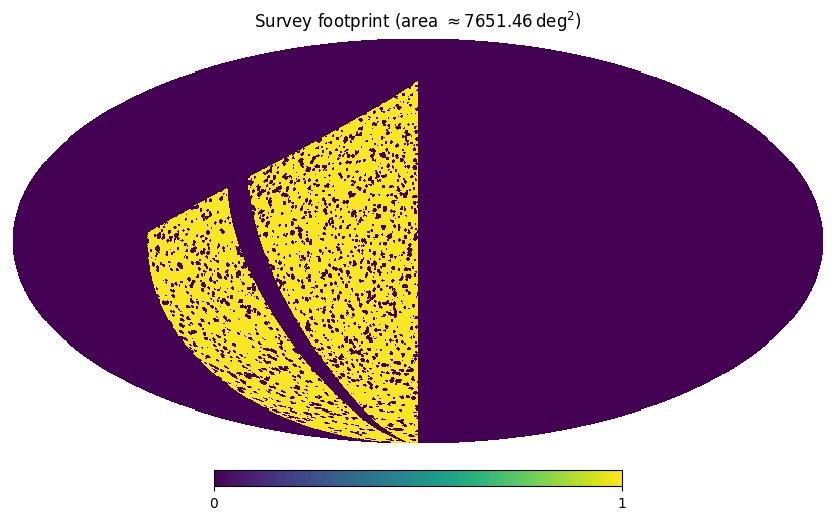

In [9]:
hpinds_fullmaskmap, _ = orpheus.cat2hpx(lon=fskycat['ra'], lat=fskycat['dec'], nside=nside_mask, return_indices=True)
_areaapprox = np.sum(orpheus.cat2hpx(lon=fskycat['ra'], lat=fskycat['dec'], nside=4096, return_indices=True)[0])*hp.nside2pixarea(4096, degrees=True)
hp.mollview(hpinds_fullmaskmap, title=r"Survey footprint (area $\approx %.2f \, \rm{deg}^2$)"%_areaapprox)
plt.show()

Now let's define the shape catalog

In [10]:
shapecat = orpheus.SpinTracerCatalog(
    spin=2,
    pos1=fskycat['ra'],
    pos2=fskycat['dec'],
    tracer_1=-fskycat['gamma1'],
    tracer_2=-fskycat['gamma2'],
    units_pos1='deg',
    units_pos2='deg',
    geometry='spherical')
shapecat.ngal

141222590

## Computation of the full-sky aperture mass map

### Define setup

For our example let us choose the Crittenden filter function and evaluate it at a filter size of 20' across the celestial sphere with a healpix resolution of 4096. Although the Crittenden Q-filter formally extends to infinity one can show that cutting it at about four times the aperture radius provides convergence at the 0.1 percent-level; `orpheus` chooses this cutoff as well. To reduce the computational burden we make use of the Tree-approximation and we fix our choice of resolutions in `tree_nsides`; note that for small aperture radii or low-density catalogs the brute-force calculation, enabled by setting `method="Discrete"`, is the most efficient choice. Similar to the NPCF estimators, the angular accuracy of the hierarchical approximation is governed by the `rmin_pixsize` parameter.

In [11]:
nside=4096 # Resolution of the grid on which the aperture mass map is evaluated
R_ap=20. # Aperture radius in `sep_units`
filter_form="C02" # Chosen filter function
sep_units="arcmin" # Separation units of R_ap
method="Tree" # Method for computation, "Discrete" for brute-force or "Tree" for tree-based approximation
tree_nsides=[0, 8192, 4096, 2048] # Healpix resolution of the tree cells (0.43', 0.86', 1.7'); 0=discrete; rule of thumb for the finest cell: d=1/sqrt(nbar)
rmin_pixsize=20 # Angular resolution within the tree-approximation. The worst-case angular resolution is given by 180/pi/rmin_pixsize degrees.
nside_hash=1024 # Resolution of the spatial hash used for efficient range searching on the sphere
nthreads=48
verbosity=2

aperturemap = orpheus.SphericalMap(nside=nside, 
                                   R_ap=R_ap, filter_form=filter_form, sep_units=sep_units, 
                                   method=method,tree_nsides=tree_nsides,rmin_pixsize=rmin_pixsize, nside_hash=nside_hash, 
                                   nthreads=nthreads, verbosity=verbosity)

### Perform computation

We compute the aperture mass map following the usual `.process` paradigm. In this process, `orpheus` computes the complex-valued aperture mass map with their associated shape-noise-based variance map, aperture coverage maps, as well as aperture normalisation. The latter ones are computed using either the traditional poisson normalisation or a Q-weighted version of the latter.

In [12]:
%%time
aperturemap.process(shapecat)

NOTE: no mask given; footprint inferred at nside=2048 (14.7 tracers per cell, 9579165 cells).
  band 0: nside_red=0 nside_nav=8192 nreds=141222590 ncells=92253333 shuffle=0
  band 1: nside_red=8192 nside_nav=8192 nreds=92253333 ncells=92253333 shuffle=0
  band 2: nside_red=4096 nside_nav=4096 nreds=37341361 ncells=37341361 shuffle=0
  band 3: nside_red=2048 nside_nav=2048 nreds=9579165 ncells=9579165 shuffle=0
.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 8h 17min 40s, sys: 44.2 s, total: 8h 18min 25s
Wall time: 10min 43s


## Interpretation of results

Now let us plot some maps:

* We can access the aperture mass maps by the `SphericalMap.Map` property. They hold the complex aperture measure $M=M_{ap}+iM_\times$ where the normalisation is done using the actual counts within the aperture. Plotting the E- and B- mode separately we note no systematic pattern in the E-Mode, but observe that the B-Modes seem to have a wider spread near the edges of the survey mask.
* We can assess this more quantitatively by looking at the aperture coverage map, accessible via the `SphericalMap.coverage` property. This holds the coverage for two conventions; index 0 for fractional coverage of the area and index=1 for Q-weighted fractional coverage. In order to control the leaked B-Modes we usually opt for the Q-weighted coverage. Note that we define aperture coverage as the fraction of the aperture that is not contained within the survey footprint.
* With these two arrays in hand it is easy to perform a coverage-based selection. In our example we only consider apertures for which the Q-weighted coverage is less than a percent which keeps about a quarter of the original apertures. With this cut we can clearly see that the level of B-modes decreases significantly

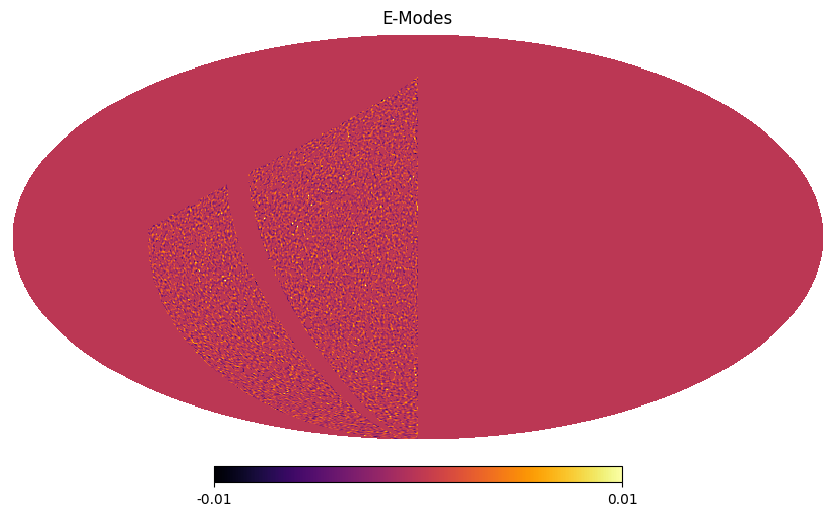

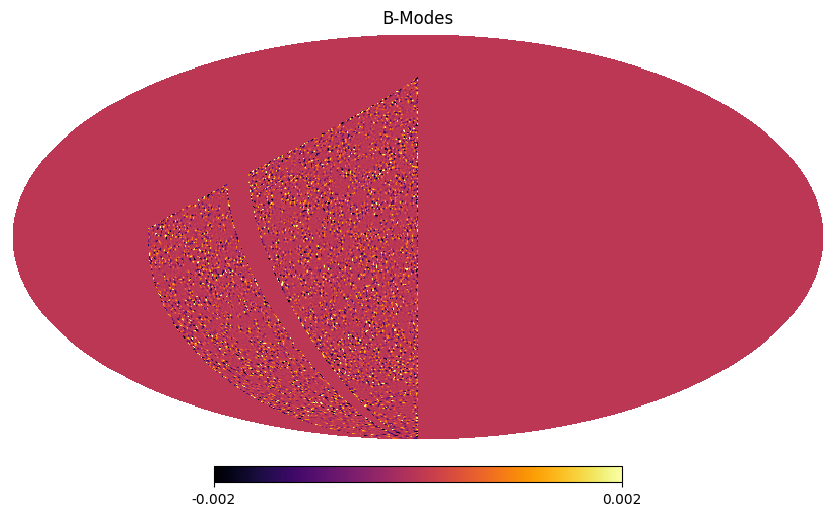

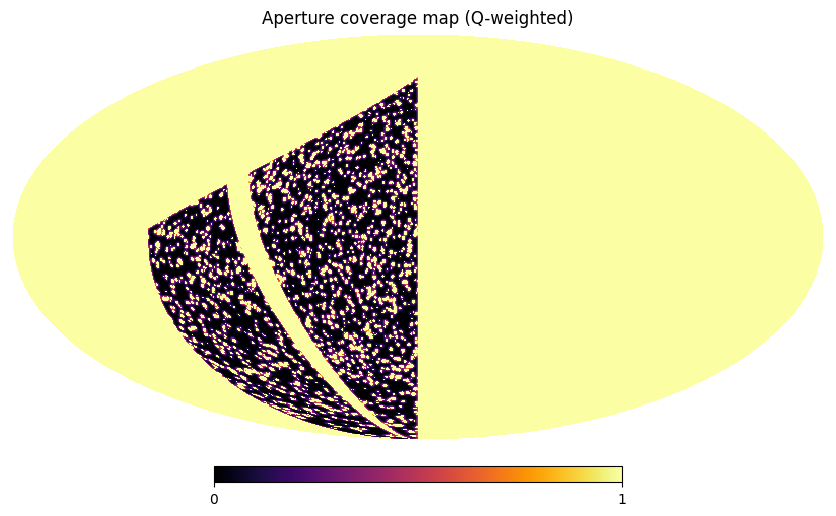

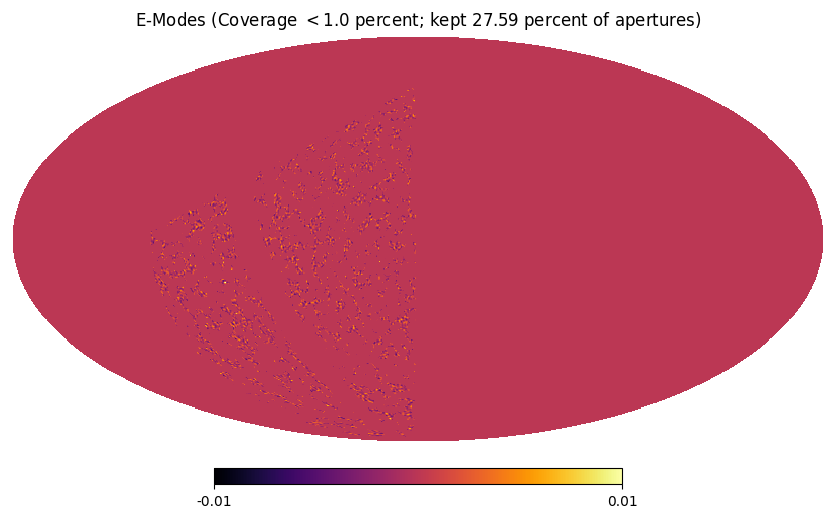

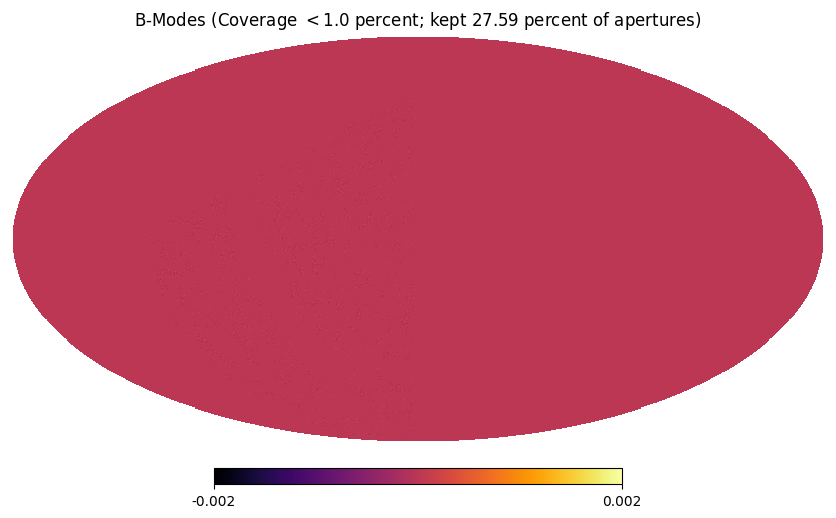

In [13]:
# Find apertures for which the Q-weighted coverage is less than 1%
coverage_cut = 0.01
incovcut = aperturemap.coverage<coverage_cut
infoot = aperturemap.norm>0
frac_kept = np.sum(incovcut,axis=1)/np.sum(infoot,axis=1)
convention_cov = 1 # Convention on how to assess aperture coverage. 0: covered area, 1: covered Q-weighted area

# Plot aperture mass map (no coverage cuts)
hp.mollview(aperturemap.Map[0].real,nest=True,min=-0.01,max=0.01,title="E-Modes",cmap="inferno")
plt.show()
hp.mollview(aperturemap.Map[0].imag,nest=True,min=-0.002,max=0.002,title="B-Modes",cmap="inferno")
plt.show()

# Plot aperture coverage map
hp.mollview(aperturemap.coverage[convention_cov],nest=True,title="Aperture coverage map (Q-weighted)",cmap="inferno")
plt.show()

# Plot aperture mass map (with coverage cuts)
hp.mollview(aperturemap.Map[0].real*incovcut[convention_cov],nest=True,min=-0.01,max=0.01,title=r"E-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")
plt.show()
hp.mollview(aperturemap.Map[0].imag*incovcut[convention_cov],nest=True,min=-0.002,max=0.002,title=r"B-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")
plt.show()

We can also compress the information of the maps into the aperture mass pdf. Here we can clearly see how the different choices of the coverage cutoff affect the shape. 

* For the E-Mode the shape around the peak is not strongly altered, however the tails of the distribution become significantly wider in both directions. While the mean does not seem to be strongly affected, the higher cumulants are.
* A similar observation holds for the B-Mode. As the B-Mode itself is expected to follow a gaussian distribution, the inclusion of partially covered apertures does not introduce significant skewness, but widens the spread.
* Heuristically this can be interpreted as smaller apertures carrying less signal and therefore having a larger intrinsic scatter. So both pdfs are convolved by the effective noise profile of the apertures. Note that this is a heuristic; in particular it assumes that the B-Mode leakage due to partially covered apertures is symmetrically distributed which can be the case for sufficiently large survey footprints but might not be always given.

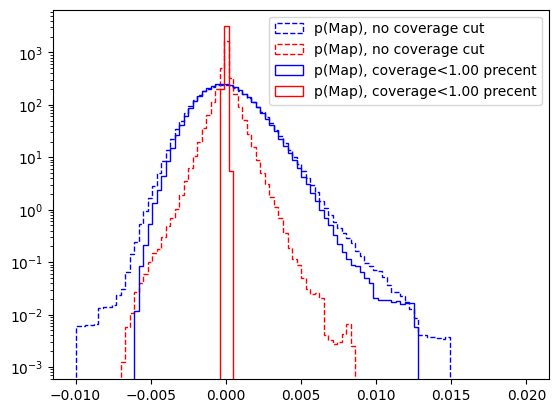

All apertures: E(Map)=-8.83 x 10^-6, var(Map)=2.99 x 10^-6
All apertures: E(Mx) =-1.56 x 10^-6, var(Mx) =0.33 x 10^-6
With covcut:   E(Map)=12.59 x 10^-6, var(Map)=2.64 x 10^-6
With covcut:   E(Mx) =0.12 x 10^-6, var(Mx) =0.00 x 10^-6


In [14]:
ap_nocut = aperturemap.Map[0][infoot[0]]
ap_covcut = aperturemap.Map[0][incovcut[convention_cov]]
bins = np.linspace(-0.01,0.02,101)
plt.hist(ap_nocut.real,bins=bins,histtype="step",density=True,color="blue", linestyle="dashed", label="p(Map), no coverage cut")
plt.hist(ap_nocut.imag,bins=bins,histtype="step",density=True,color="red", linestyle="dashed", label="p(Map), no coverage cut")
plt.hist(ap_covcut.real,bins=bins,histtype="step",density=True,color="blue", label="p(Map), coverage<%.2f precent"%(100*coverage_cut))
plt.hist(ap_covcut.imag,bins=bins,histtype="step",density=True,color="red", label="p(Map), coverage<%.2f precent"%(100*coverage_cut))
plt.legend()
plt.yscale('log')
plt.show()

print("All apertures: E(Map)=%.2f x 10^-6, var(Map)=%.2f x 10^-6"%(1e6*np.mean(ap_nocut.real),1e6*np.var(ap_nocut.real)))
print("All apertures: E(Mx) =%.2f x 10^-6, var(Mx) =%.2f x 10^-6"%(1e6*np.mean(ap_nocut.imag),1e6*np.var(ap_nocut.imag)))
print("With covcut:   E(Map)=%.2f x 10^-6, var(Map)=%.2f x 10^-6"%(1e6*np.mean(ap_covcut.real),1e6*np.var(ap_covcut.real)))
print("With covcut:   E(Mx) =%.2f x 10^-6, var(Mx) =%.2f x 10^-6"%(1e6*np.mean(ap_covcut.imag),1e6*np.var(ap_covcut.imag)))

Finally, we can assess the consistency of masking by comparing the variance of the map with the aperture mass variance at the same scale when computed from the shear 2pt correlation function on the same catalog. In the following cell we perform this computation with a setup that mimics the one we used for the aperture mass map.

In [15]:
%%time
gg = orpheus.GGCorrelation(min_sep=0.1, max_sep=160., binsize=0.1, nthreads=48, verbosity=2, rmin_pixsize=20, tree_resos=[0., 0.5, 1., 2.], process_spherical=True)
gg.process(shapecat)

  band 0: nside_red=0 nside_nav=1024 nreds=141222590 ncells=2396837 shuffle=0
  band 1: nside_red=8192 nside_nav=8192 nreds=92253333 ncells=92253333 shuffle=0
  band 2: nside_red=4096 nside_nav=4096 nreds=37341361 ncells=37341361 shuffle=0
  band 3: nside_red=2048 nside_nav=2048 nreds=9579165 ncells=9579165 shuffle=0
.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 9h 42min 58s, sys: 36.3 s, total: 9h 43min 35s
Wall time: 12min 19s


Plotting the two results confirms our previous findings:

* The second-order aperture mass inferred from the map without a coverage cut is significantly biased. Applying the cut reduces this bias significantly. Note that we don't expect perfect equivalence as the coverage cut removes about three-quarters of the apertures, meaning that both estimators operate on different footprints
* The cross-aperture mass variance is even more affected by the coverage cut. In order to make the impact visible we scale the B-Modes of the 2pcf and the map-based inference without a coverage cut by a factor of 100 and we find those to agree reasonably well. On the other hand, the B-Mode variance of the map without any coverage cuts exceeds the 2pcf-based result by more than an order of magnitude.

_Note that this test is somewhat similar to what we would do in the_ ``DirectEstimator`` _classes within_ ``orpheus``. _In those, however, we are not mainly interested in creating maps, but to compute unbiased cumulant-based summary statistics from them directly. Certain higher-order correction factors and nontrivial weighting schemes that can be found in there are not included in the aperture mass mapping module._

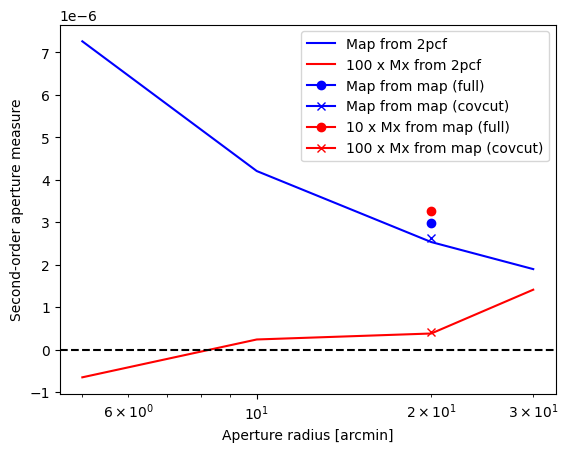

In [16]:
apradii = np.array([5., 10., 20, 30])
gg_map2 = gg.computeMap2(radii=apradii)
plt.semilogx(apradii, gg_map2[0,0],color="blue", label="Map from 2pcf")
plt.semilogx(apradii, 100*gg_map2[2,0],color="red", label="100 x Mx from 2pcf")
plt.plot([20],np.var(ap_nocut.real),marker='o',color="blue", label="Map from map (full)")
plt.plot([20],np.var(ap_covcut.real),marker='x',color="blue", label="Map from map (covcut)")
plt.plot([20],10*np.var(ap_nocut.imag),marker='o',color="red", label="10 x Mx from map (full)")
plt.plot([20],100*np.var(ap_covcut.imag),marker='x',color="red", label="100 x Mx from map (covcut)")
plt.axhline(0,color="black", ls="--")
plt.legend()
plt.xlabel("Aperture radius [arcmin]")
plt.ylabel("Second-order aperture measure")
plt.show()

## Associated aperture mass S/N maps

Given that we compute both, the aperture mass maps and their inferred variance maps, we can also infer the aperture mass signal-to-noise maps. As the variance is computed using a shape-noise-only-based approximation, we first add this noise on top of the catalog.

In [24]:
sigma_eps_comp = 0.26

rng = np.random.RandomState(seed=42)
shapecat_noisy = orpheus.SpinTracerCatalog(
    spin=2,
    pos1=fskycat['ra'],
    pos2=fskycat['dec'],
    tracer_1=-fskycat['gamma1']+rng.normal(loc=0,scale=sigma_eps_comp,size=shapecat.ngal),
    tracer_2=-fskycat['gamma2']+rng.normal(loc=0,scale=sigma_eps_comp,size=shapecat.ngal),
    units_pos1='deg',
    units_pos2='deg',
    geometry='spherical')

In [25]:
nside=4096
R_ap=4.
filter_form="C02"
sep_units="arcmin"
method="Discrete"
nside_hash=1024
nthreads=48
verbosity=2

aperturemap_noisy = orpheus.SphericalMap(
    nside=nside, 
    R_ap=R_ap, filter_form=filter_form, sep_units=sep_units, 
    method=method,tree_nsides=tree_nsides,rmin_pixsize=rmin_pixsize, nside_hash=nside_hash, 
    nthreads=nthreads, verbosity=verbosity)

In [26]:
%%time
aperturemap_noisy.process(shapecat_noisy)

NOTE: no mask given; footprint inferred at nside=2048 (14.7 tracers per cell, 9579165 cells).
  band 0: nside_red=0 nside_nav=1024 nreds=141222590 ncells=2396837 shuffle=0
.........|.........|.........|.........|.........|.........|.........|.........|.........|.........|
CPU times: user 1h 47min 16s, sys: 12.9 s, total: 1h 47min 29s
Wall time: 2min 32s


/tmp/ipykernel_355457/2039998881.py:13: RuntimeWarning: invalid value encountered in divide
  hp.mollview(_mapmap.real/_mapmapstd,nest=True,min=-3,max=3,title="E-Modes",cmap="inferno")


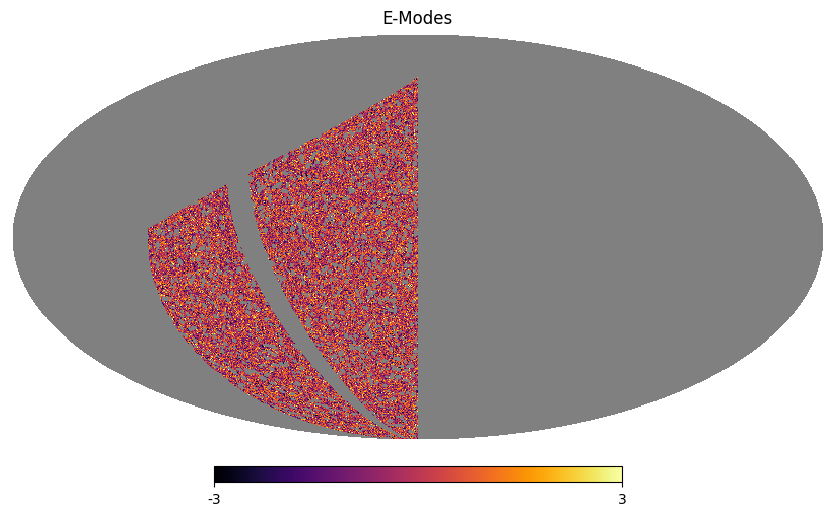

/tmp/ipykernel_355457/2039998881.py:15: RuntimeWarning: invalid value encountered in divide
  hp.mollview(_mapmap.imag/_mapmapstd,nest=True,min=-3,max=3,title="B-Modes",cmap="inferno")


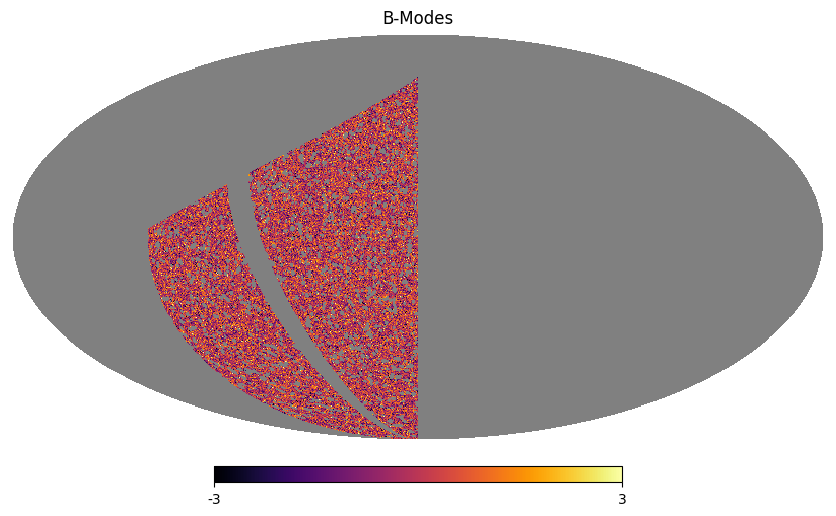

/tmp/ipykernel_355457/2039998881.py:19: RuntimeWarning: invalid value encountered in divide
  hp.mollview(_mapmap.real*_covconv/_mapmapstd,nest=True,min=-3,max=3,title=r"E-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")


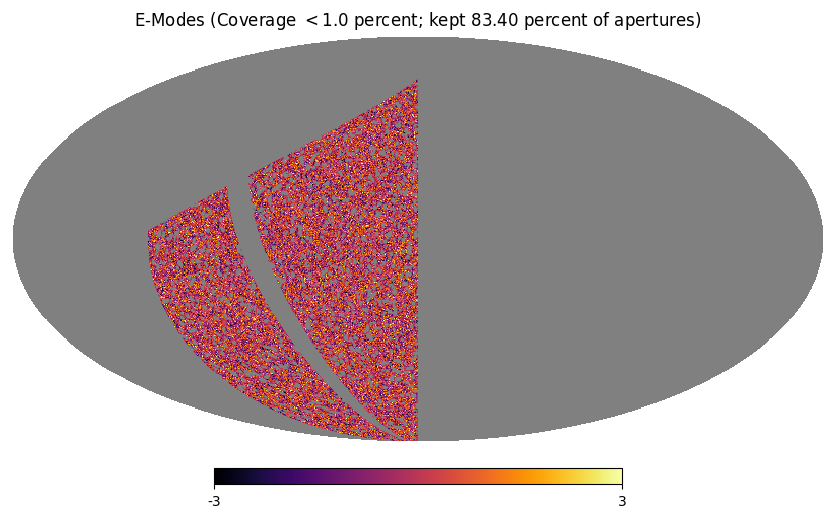

/tmp/ipykernel_355457/2039998881.py:21: RuntimeWarning: invalid value encountered in divide
  hp.mollview(_mapmap.imag*_covconv/_mapmapstd,nest=True,min=-3,max=3,title=r"B-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")


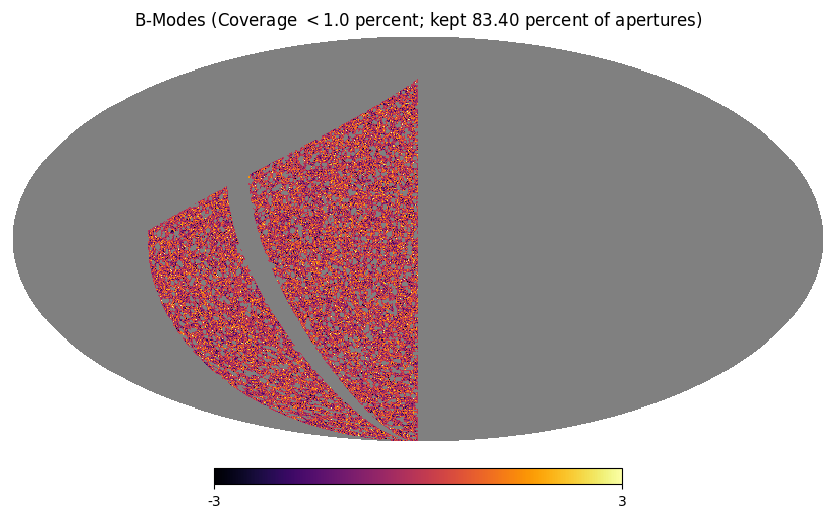

In [34]:
# Find apertures for which the Q-weighted coverage is less than 1%
coverage_cut = 0.01
incovcut = aperturemap_noisy.coverage<coverage_cut
infoot = aperturemap_noisy.norm>0
frac_kept = np.sum(incovcut,axis=1)/np.sum(infoot,axis=1)
convention_cov = 1 # Convention on how to assess aperture coverage. 0: covered area, 1: covered Q-weighted area


_mapmap = aperturemap_noisy.Map[0]
_mapmapstd = np.sqrt(aperturemap_noisy.var[0])
_covconv = incovcut[convention_cov]
# Plot aperture mass S/N map (no coverage cuts)
hp.mollview(_mapmap.real/_mapmapstd,nest=True,min=-3,max=3,title="E-Modes",cmap="inferno")
plt.show()
hp.mollview(_mapmap.imag/_mapmapstd,nest=True,min=-3,max=3,title="B-Modes",cmap="inferno")
plt.show()

# Plot aperture mass map (with coverage cuts)
hp.mollview(_mapmap.real*_covconv/_mapmapstd,nest=True,min=-3,max=3,title=r"E-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")
plt.show()
hp.mollview(_mapmap.imag*_covconv/_mapmapstd,nest=True,min=-3,max=3,title=r"B-Modes (Coverage $<%.1f$ percent; kept %.2f percent of apertures)"%(100*coverage_cut,100*frac_kept[convention_cov]),cmap="inferno")
plt.show()